In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**ML - Aprendizaje No Supervisado**

n la mayoría de los casos, nuestros datos no vienen con etiquetas. Etiquetarlos manualmente puede ser costoso y llevar mucho tiempo. Por eso existen técnicas de aprendizaje no supervisado (Unsupervised Learning), que nos permiten analizar y descubrir patrones en los datos sin necesidad de etiquetas previas.

El Clustering es una técnica popular de aprendizaje no supervisado que agrupa datos similares en conjuntos llamados clusters. Esto ayuda a descubrir patrones y segmentar información, siendo útil en áreas como la segmentación de clientes, análisis de datos, reducción de dimensiones, detección de anomalías y motores de búsqueda

**K-Means**

El algoritmo de K-Means es uno de los más usados a la hora de aplicar Clustering, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

# Número aleatorio de centros entre 1 y 20
n_centers = random.randint(1, 20)
# Generar centros aleatorios separados adecuadamente
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)  # desviación estándar uniforme

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)




#print(f"Se generaron {n_centers} clusters con {'X' if fix_x else 'Y'} fijo en {fixed_value}")
print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 12
Coordenadas de los centroides:
[[-1.36359803  7.11396309]
 [-5.60707314  9.45575858]
 [ 7.90888268 -1.25607643]
 [-1.89165646 -2.39355005]
 [ 1.4429744   4.31085708]
 [ 2.60604328  6.34107383]
 [ 9.11192888  8.80557311]
 [-5.63528232  4.96079583]
 [ 2.08643661  1.92831773]
 [-6.85698157  7.34873982]
 [ 9.27567002  4.37934267]
 [ 1.2350375  -9.38975335]]


In [ ]:
import matplotlib.pyplot as plt
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

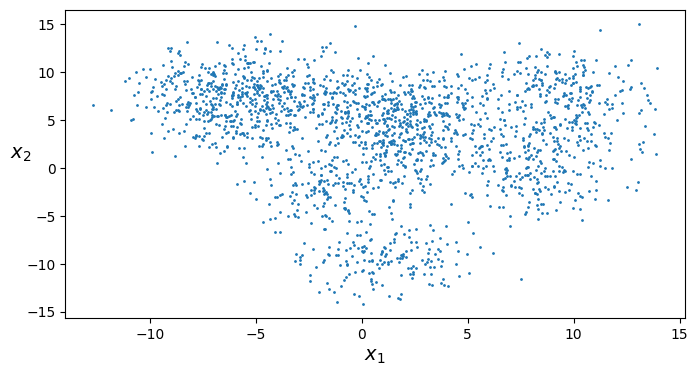

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En Scikit-Learn puedes usar el objeto KMeans, indicando el número de clusters deseado.

In [ ]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([ 0,  5, 10, ...,  6,  1,  0], dtype=int32)

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([7, 4, 7, 7], dtype=int32)

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

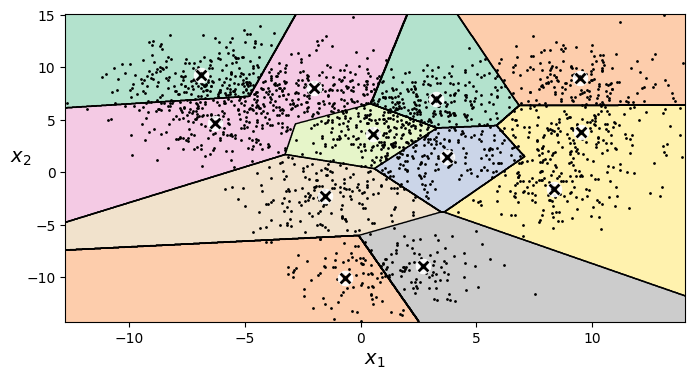

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

En lugar de asignar un grupo a cada muestra (hard clustering) se le puede asignar una puntuación (soft clustering) en función de su distancia al centroide.

In [ ]:
kmeans.transform(X_new)

array([[ 5.98765397, 10.01716786, 12.07761801, 11.75493051,  3.78972412,
         6.32443186,  6.84226377,  1.76943448,  9.11950056,  9.68222716,
         4.5040677 , 11.32013171],
       [ 5.03842728, 12.27807432, 12.60401048,  9.50173105,  0.93258455,
         7.80960829,  9.66734076,  2.97829904,  6.47079926,  6.75810149,
         6.2015354 , 10.99472597],
       [ 7.43325337,  7.37665026, 13.26631771, 13.82679097,  6.92577132,
         5.09962902,  3.70311756,  3.60883636, 12.27367549, 12.53821026,
         5.43944871, 13.28113617],
       [ 7.71594149,  7.80548409, 12.77442403, 14.04909317,  6.83083495,
         5.59075627,  3.96161263,  3.73598926, 12.09550428, 12.58025887,
         4.95993007, 12.83151087]])

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.

In [ ]:

kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)

kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=12, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=12, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=12, n_init=1, random_state=5)


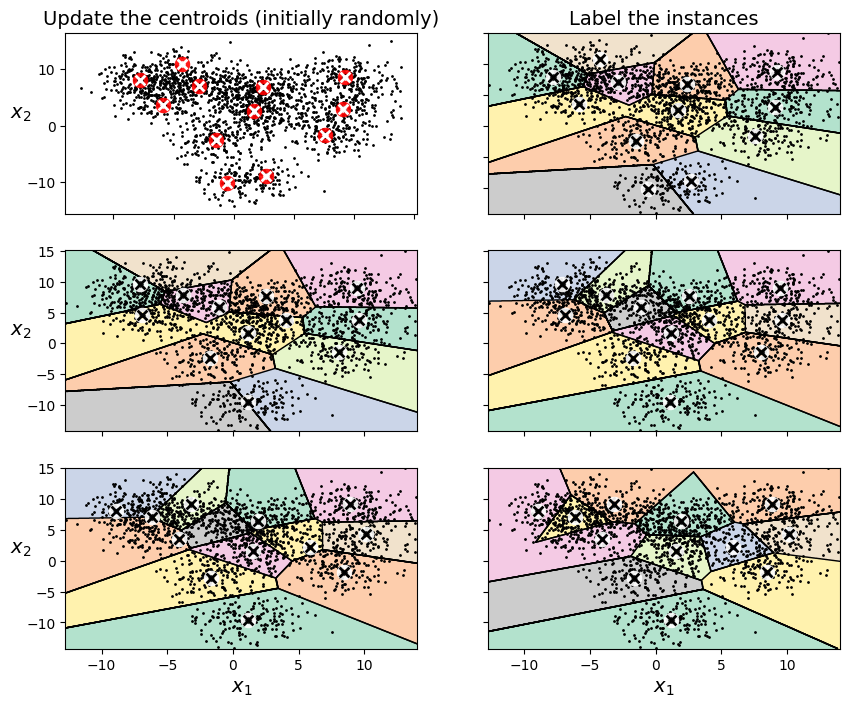

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

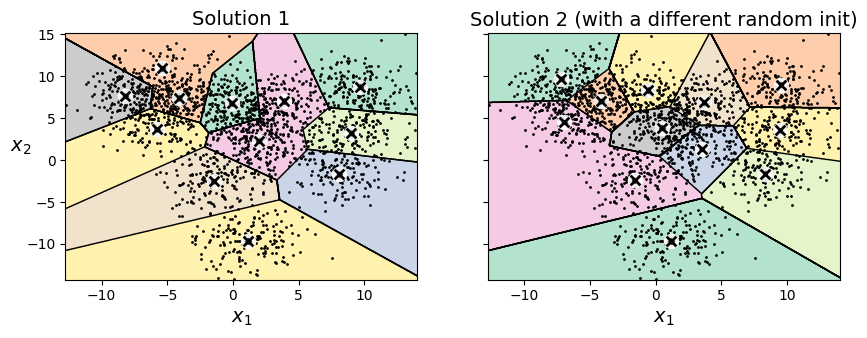

In [ ]:


kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()



Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en Scikit-Learn.

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=12, n_init=10,
       random_state=11)


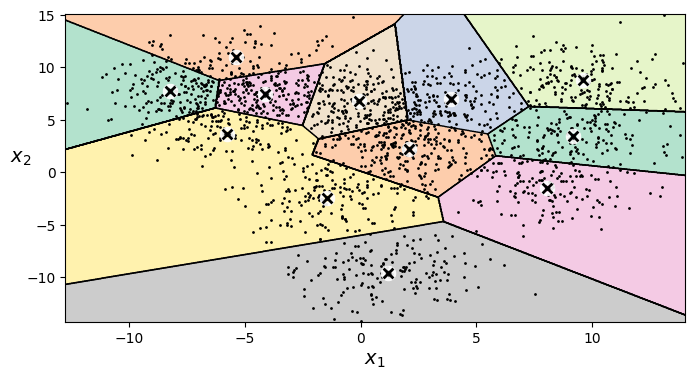

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Existen varias formas de mejorar el algoritmo K-Means. Por ejemplo, hay versiones más rápidas (como la que usa Scikit-Learn por defecto, que optimiza el cálculo de distancias) y también está el mini-batch K-Means, ideal cuando el conjunto de datos es tan grande que no cabe en memoria. A continuación veremos cómo funciona este último usando el dataset sintetico, empleando el objeto [MiniBatchKMeans]

In [ ]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [ ]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [ ]:
best_kmeans.score(X)

-24761.247829214764

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.

**Encontrando el número óptimo de grupos**

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el silhouette score, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.3542287000307056)

Calculando la métrica para diferentes números de clusters podemos encontrar el valor óptimo.

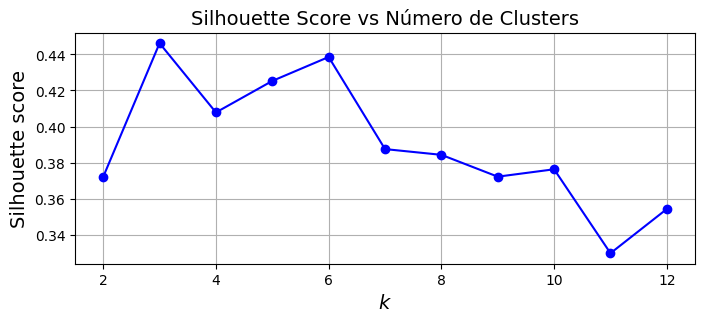

In [ ]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

 **METODO CODO**

Calcula la inercia para distintos valores de k

In [ ]:
def metodo_codo(X, max_k):
    inertias = []
    K = range(1, max_k + 1)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(8, 4))
    plt.plot(K, inertias, "bo-")
    plt.xlabel("Número de clusters (k)", fontsize=14)
    plt.ylabel("Inercia", fontsize=14)
    plt.title("Método del codo", fontsize=14)
    plt.grid(True)
    plt.show()

    return inertias

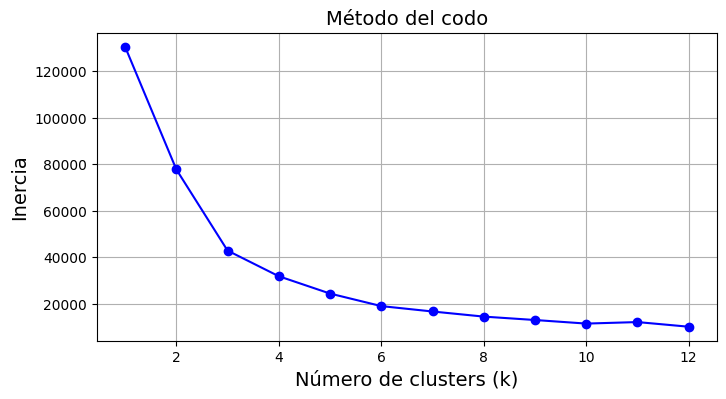

In [ ]:
inertias = metodo_codo(X, max_k)

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

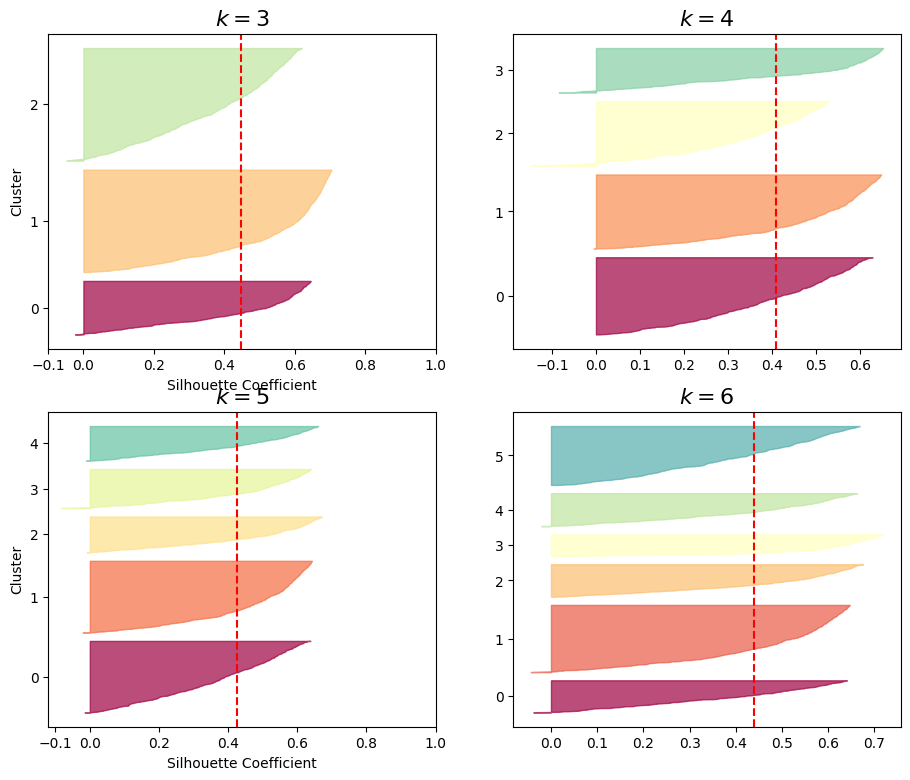

In [ ]:

from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

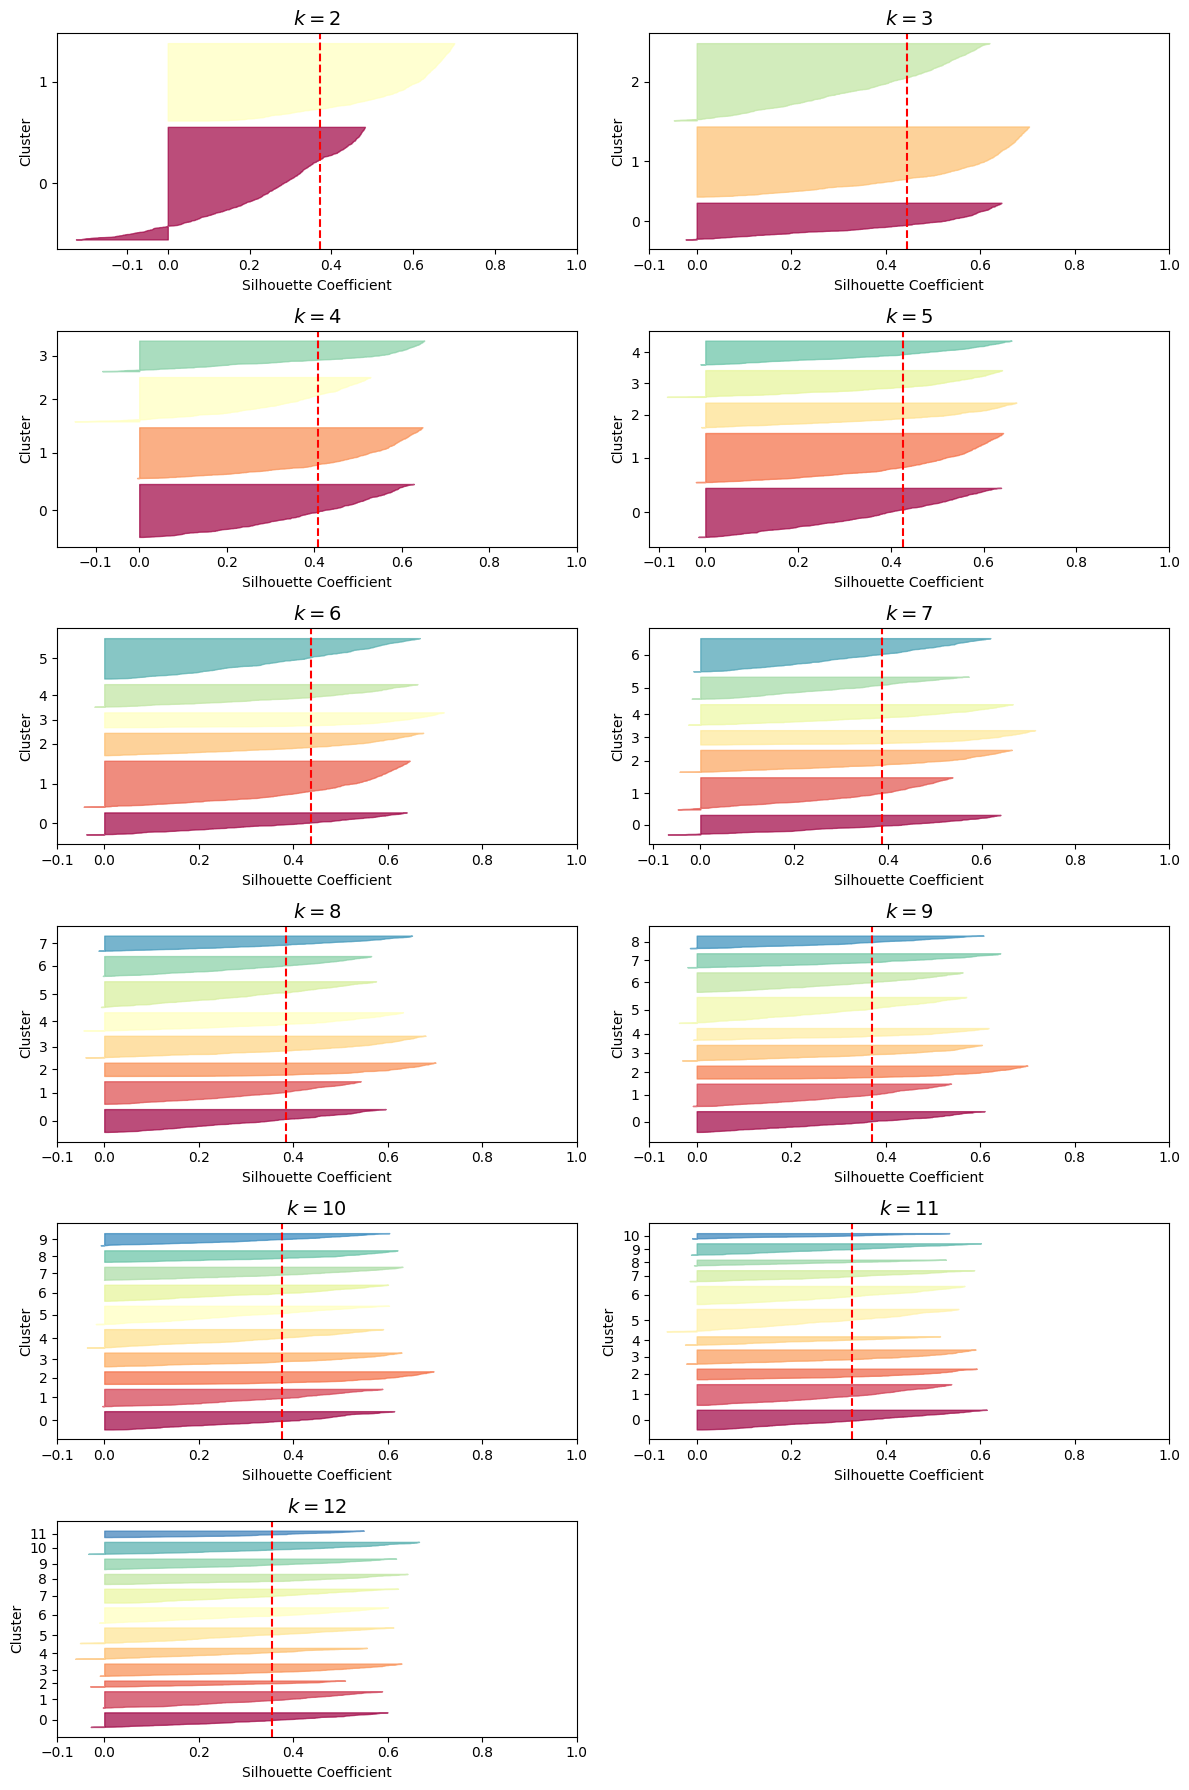

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

**Aprendizaje semi-supervisado**

El aprendizaje semi-supervisado, también conocido como Semi-supervised Learning, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset sign_mnist y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.

In [ ]:
data = np.loadtxt('/content/drive/MyDrive/tareas/ANS/data/sign_mnist.csv',
                  delimiter=',',
                  skiprows=1)

In [ ]:
X=data[:,1:]
y=data[:,0]
print("numero de filas,numero de columanas")
X.shape

numero de filas,numero de columanas


(27455, 784)

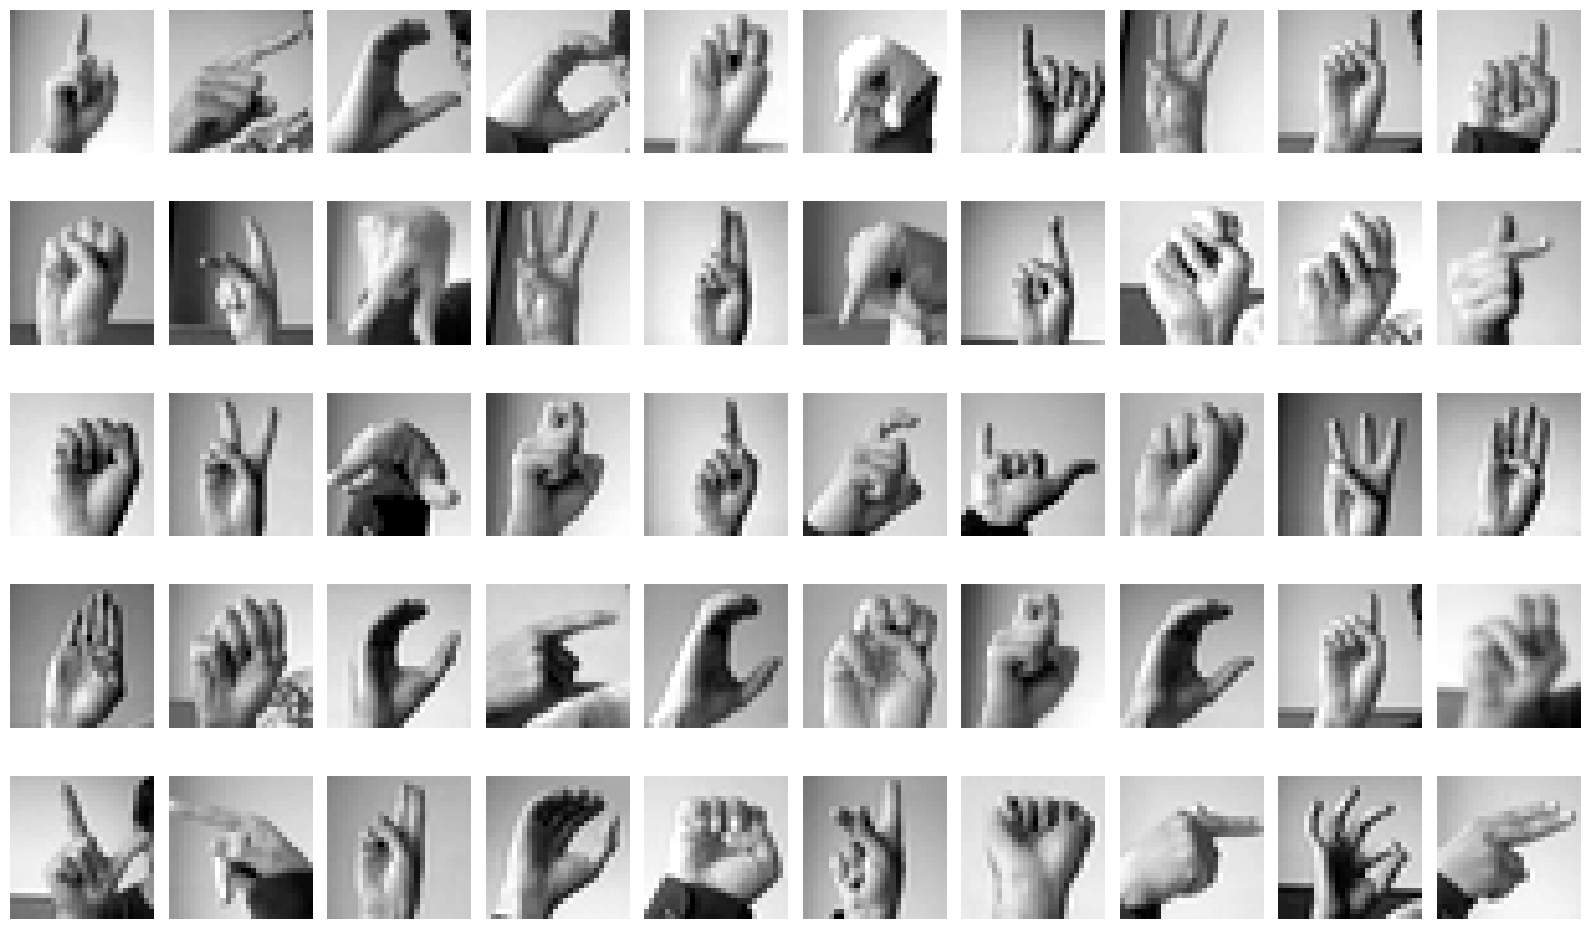

In [ ]:
plt.figure(figsize=(16, 10))
for  i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(X[i].reshape(28, 28),cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print("rango aproximado de valores:", X_train.min(), "a", X_train.max())

(21964, 784)
(5491, 784)
rango aproximado de valores: 0.0 a 255.0


In [ ]:
#normaliza
X_train= X_train/255.0
X_test = X_test/255.0

Imaginemos que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, 150 grupos. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.


In [ ]:
from sklearn.cluster import KMeans as kms
k=150 # número de clusters
kmeans =kms(n_clusters=k ,random_state=42)
X_digits_dist=kmeans.fit_transform(X_train) # distancia a cada centroide
print(X_digits_dist.shape)
print(X_digits_dist)

Seleccionamos las imágenes más representativas

In [ ]:
idxs = np.argmin(X_digits_dist, axis=0) # índice más cercano a cada centroide
X_representative_digits = X_train[idxs]   # imágenes representativas
# Obtener las etiquetas reales de las imágenes más representativas
y_representative_digits = y_train[idxs]
print(X_representative_digits.shape)
print(X_representative_digits)
print("Ejemplos representativos:", len(X_representative_digits))

(100, 784)
[[178. 180. 182. ... 220. 219. 218.]
 [ 40.  81.  91. ... 110. 109. 110.]
 [157. 158. 161. ... 197. 197. 197.]
 ...
 [141. 142. 143. ... 157. 152. 144.]
 [208. 209. 209. ... 228. 227. 223.]
 [152. 155. 159. ...  38.  42.  43.]]
Ejemplos representativos: 100


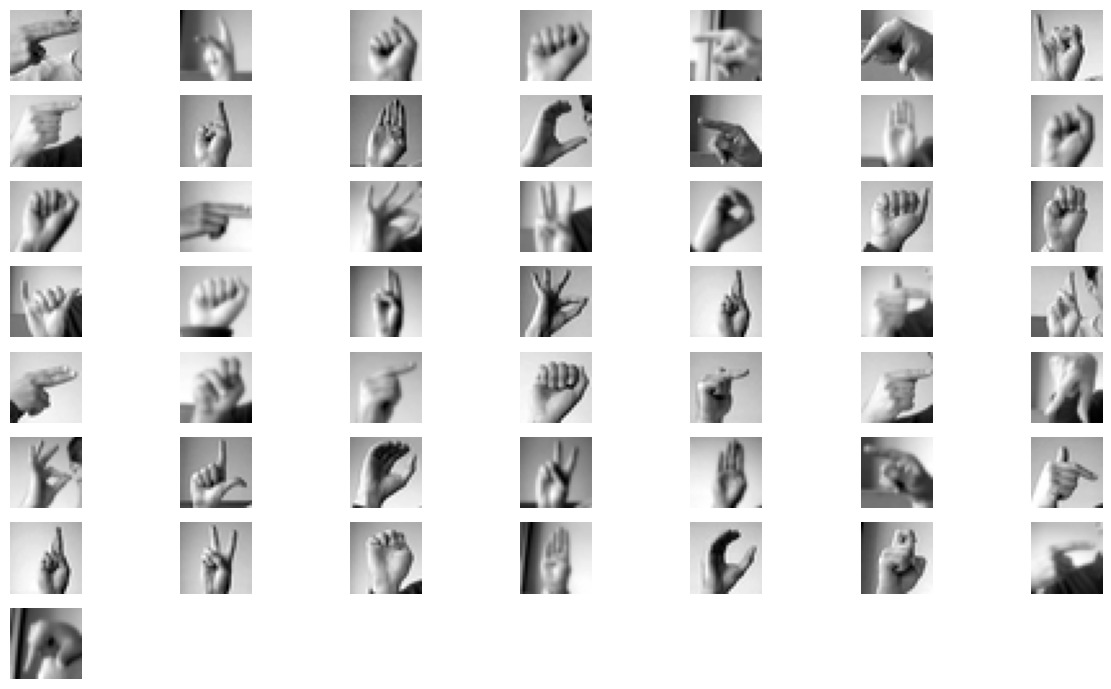

In [ ]:
plt.figure(figsize=(15, 22))
for index, X_representative_digit in enumerate(X_representative_digits[:50]):
    plt.subplot(20,7, index + 1)
    plt.imshow(X_representative_digit.reshape(28, 28),cmap='gray')
    plt.axis('off')
plt.show()

Entrenamos los clasificados usando las imagenes representativas

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
# Evaluamos el modelo en el conjunto de prueba
log_reg2.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 2.52 s, sys: 11.7 ms, total: 2.53 s
Wall time: 2.1 s


0.47841923146967763

Entrenar el mismo  modelo con 150 imagenes aleatorios ¿nos daria peores resultado?

In [ ]:
idxs = np.random.choice(len(X_train),150, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[idxs], y_train[idxs])
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1.21 s, sys: 0 ns, total: 1.21 s
Wall time: 636 ms


0.4307047896558004

a veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los más útiles y representativos. Una vez que hemos entrenado un clasificador con las imágenes más representativas, podemos aprovecharlo para etiquetar automáticamente el resto del conjunto. Para ello, asignamos a todas las imágenes de cada grupo la misma etiqueta que le dimos a su representante

In [ ]:
y_train_propagated = np.empty(len(X_train))
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]
print(y_train_propagated)

[10. 15.  0. ...  2.  7. 15.]


In [ ]:
print("Número de clases finales después de reducir:", len(np.unique(y_train_propagated)))

Número de clases finales después de reducir: 24


In [ ]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42,n_jobs=-1)
%time log_reg3.fit(X_train[:2000], y_train_propagated[:2000])
log_reg3.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 751 ms, sys: 209 ms, total: 960 ms
Wall time: 3min 6s


0.3622291021671827

A veces al intentar mejorar el modelo añadiendo mas datos eiquetados, el resultado puedes ser peor.Esto puede ocurrir  por que todas la imagenes no quedan bien agrupadas y
 se introduce el ruido  en el entrenamiento.Para evitar podemos limitar el etiquetado solo a als muetras que esten mas cerca de los representantes de cada grupo o bien recurrir a tecnicas de aprendizaje  activo para seleccionar mejor los ejemplos anotar

**Aprendisaje Activo**

El aprendizaje activo (o Active Learning) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [77]:
#Obtener las probabilidades del modelo actual
probas = log_reg3.predict_proba(X_train[:2000])

# Obtenemos el índice de la clase más probable para cada muestra
labels_ixs = np.argmax(probas, axis=1)

# Obtenemos la confianza (probabilidad máxima) de cada predicción
confidences = probas[np.arange(len(probas)), labels_ixs]

#Ordenar las imágenes de menor confianza a mayor confianza
sorted_ixs = np.argsort(confidences)


Seleccionar los 150 ejemplos más difíciles donde el modelo tiene menos confianza  

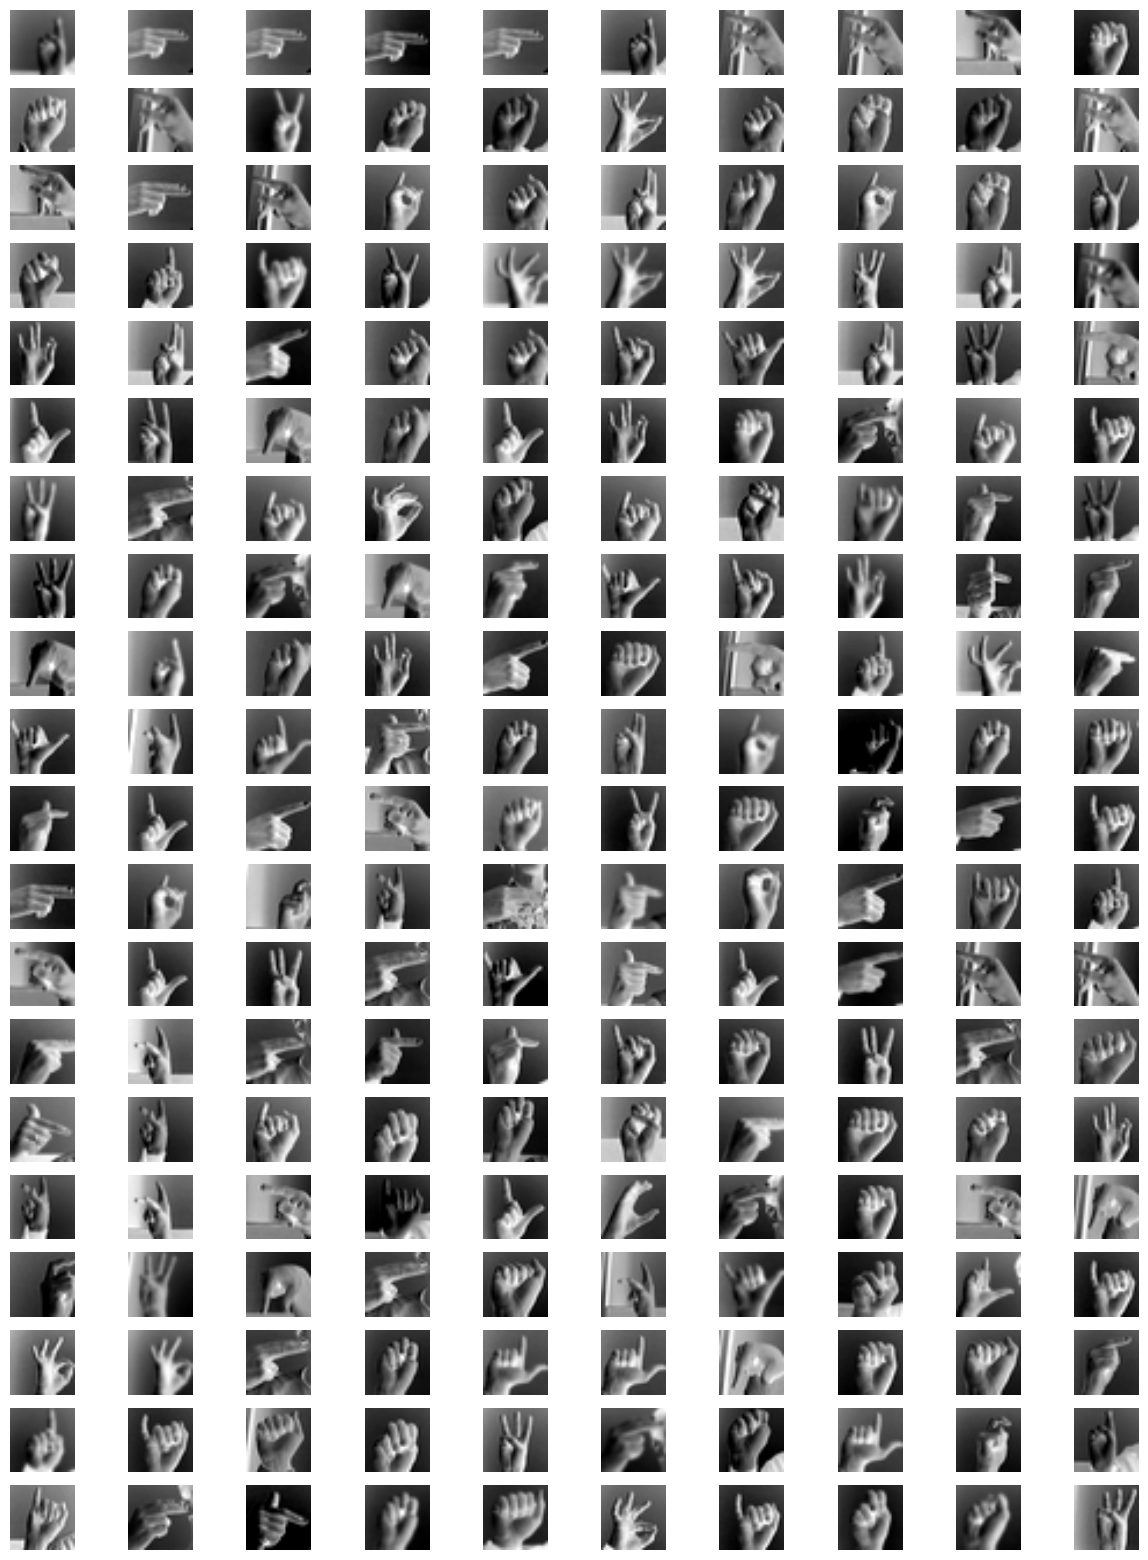

In [78]:
X_lowest = X_train[:2000][sorted_ixs[:k]]
plt.figure(figsize=(15, 20))
for index, img in enumerate(X_lowest):
    plt.subplot(20, 10, index + 1)
    plt.imshow(img.reshape(28, 28), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()


In [79]:
y_lowest = y_train[:2000][sorted_ixs[:k]]
y_lowest

array([17.,  7.,  7.,  7.,  7., 17., 15., 15., 15., 18.,  0., 15., 21.,
       12., 18.,  5., 18., 12., 18., 15., 15.,  7., 15.,  3., 18., 20.,
       18.,  3., 12., 21., 13.,  3.,  8., 21.,  5.,  5.,  5., 22., 20.,
       15.,  5., 20.,  6., 18., 18.,  8., 24., 20., 22., 15., 11., 21.,
       16., 18., 11.,  5., 18.,  7.,  8.,  8., 22.,  7.,  8.,  5., 13.,
        8., 12.,  8., 19., 22., 22., 12.,  7., 16.,  6., 24.,  8.,  5.,
       19.,  6., 16., 17., 18.,  5.,  6.,  0., 15.,  3.,  5.,  7., 24.,
       10., 11., 19., 12., 20.,  3., 18., 12.,  0., 19., 11.,  6., 15.,
        0., 21.,  0., 23.,  6.,  8.,  7.,  3., 23., 10.,  7., 19., 14.,
        6.,  8.,  3., 15., 11., 22.,  7., 24., 19., 11.,  6., 15., 15.,
        7., 10.,  7., 19., 19.,  8., 18., 22.,  7.,  0., 19., 10.,  8.,
       12., 13., 12.,  7.,  0., 13.,  5., 10., 10., 15.,  8., 11.,  2.,
        7., 18., 15., 16., 23., 22., 16.,  7.,  0., 10., 24., 13., 11.,
        8.,  5.,  5.,  7., 13., 11., 11., 16., 18.,  0.,  6.,  3

In [80]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42,n_jobs=-1)
%time log_reg5.fit(X_lowest, y_lowest)
print("Precisión usando aprendizaje activo (100 imágenes inciertas):", log_reg5.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 22.1 ms, sys: 6.21 ms, total: 28.3 ms
Wall time: 1.43 s
Precisión usando aprendizaje activo (100 imágenes inciertas): 0.299216900382444
